In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
data = pd.read_csv("Student_Performance.csv")
data.head()


,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [6]:
data.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [7]:
data.isnull().sum()

Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64

In [16]:
data.columns

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

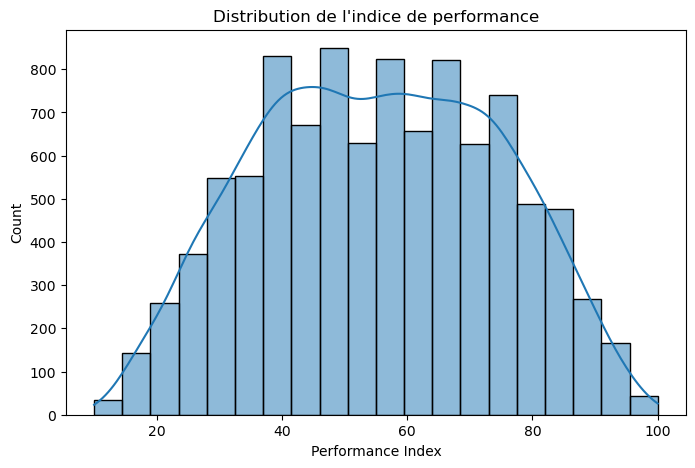

In [22]:
plt.figure(figsize=(8,5))
sns.histplot(data['Performance Index'], bins=20, kde=True)
plt.title("Distribution de l'indice de performance")
plt.show()

In [24]:
data = pd.get_dummies(data, columns=['Extracurricular Activities'], drop_first=True, dtype=int)
data.head()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index,Extracurricular Activities_Yes
0,7,99,9,1,91.0,1
1,4,82,4,2,65.0,0
2,8,51,7,2,45.0,1
3,5,52,5,2,36.0,1
4,7,75,8,5,66.0,0


<function matplotlib.pyplot.show(close=None, block=None)>

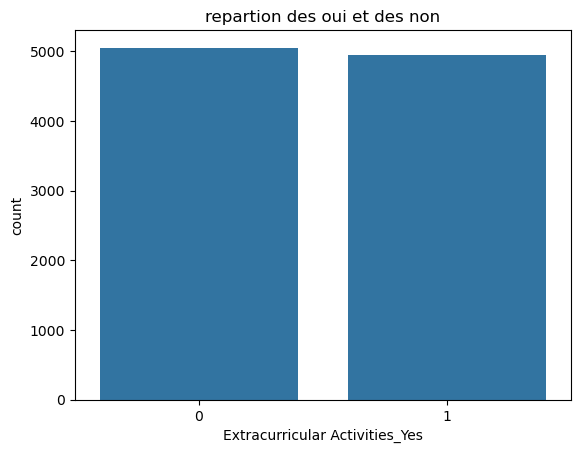

In [25]:
sns.countplot(x='Extracurricular Activities_Yes', data=data)
plt.title("repartion des oui et des non")
plt.show

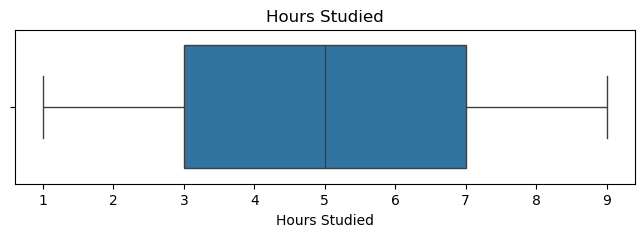

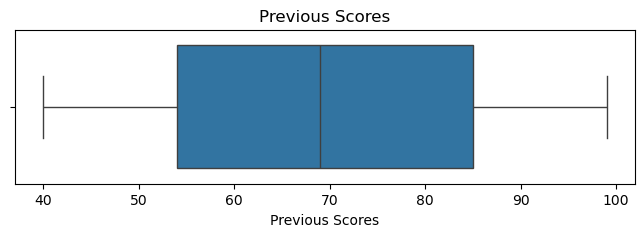

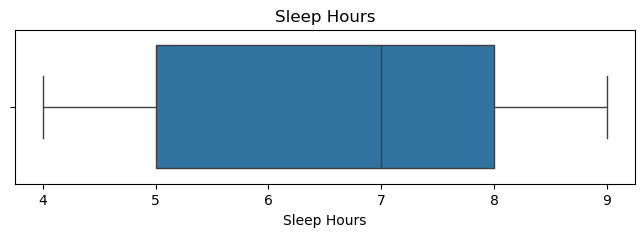

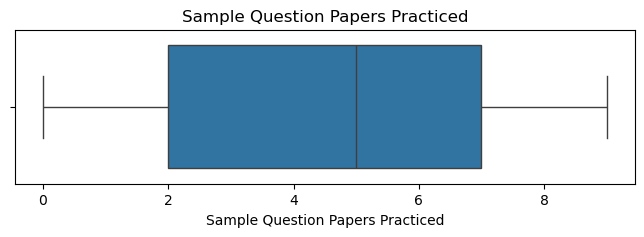

In [26]:
variables = ['Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced']
for col in variables :
    plt.figure(figsize=(8,2))
    sns.boxplot(x=data[col])
    plt.title(col)
    plt.show()

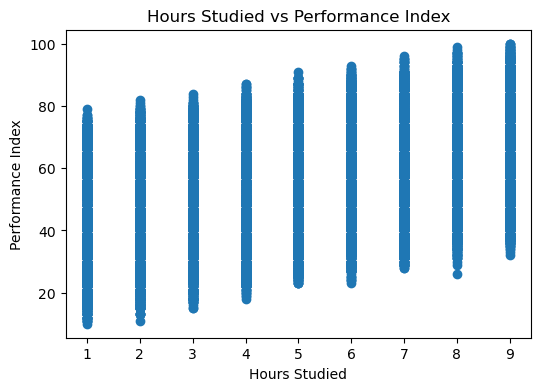

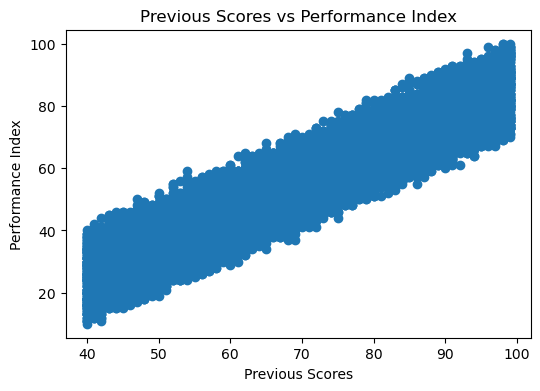

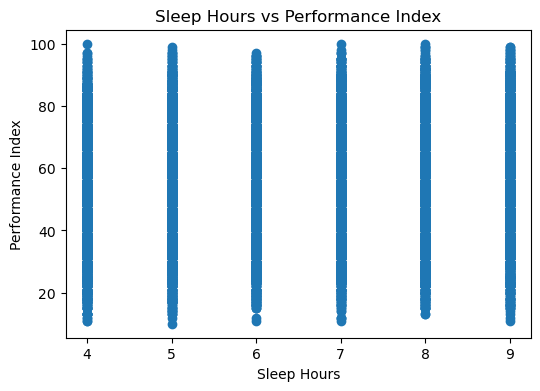

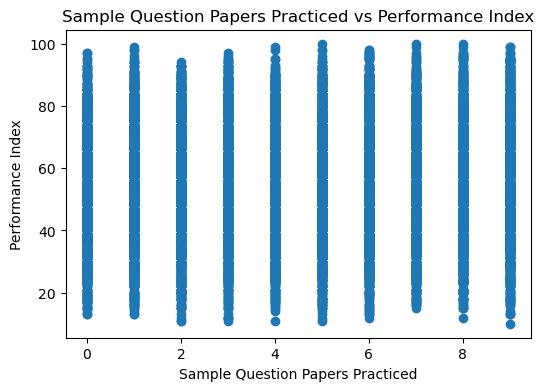

In [28]:
for col in variables:
    plt.figure(figsize=(6,4))
    plt.scatter(data[col], data['Performance Index'])
    plt.xlabel(col)
    plt.ylabel('Performance Index')
    plt.title(f'{col} vs Performance Index')
    plt.show()

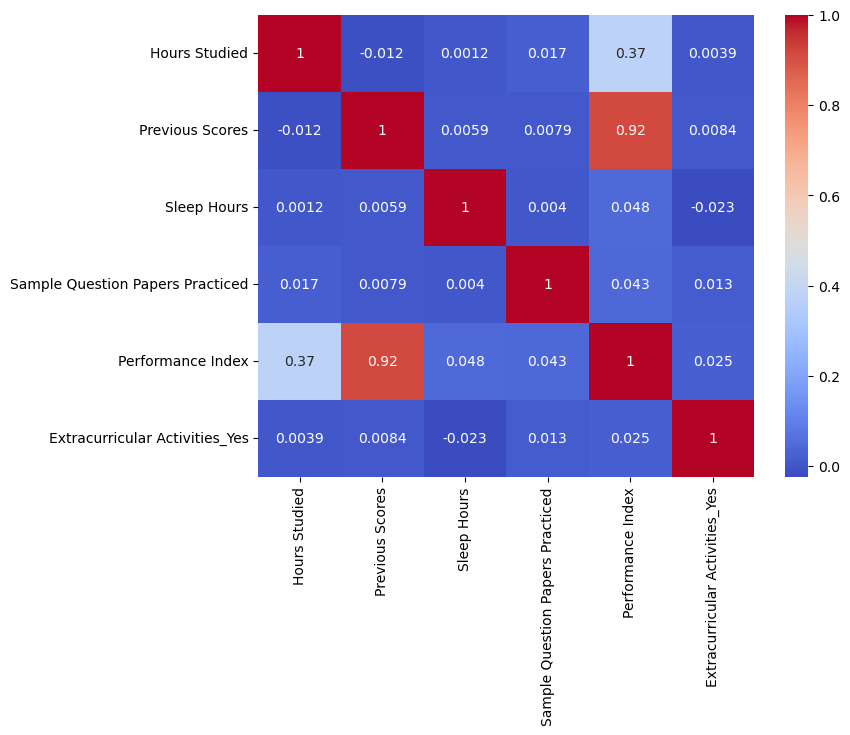

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.show()

In [31]:
X=data.drop('Performance Index', axis= 1)
y = data['Performance Index']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 7)

In [38]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(8000, 5)
(2000, 5)
(8000,)
(2000,)


In [43]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
Xtransform_test = scaler.(X_test)

In [52]:
knn = KNeighborsRegressor(n_neighbors=23)
knn.fit(X_train, y_train)

,n_neighbors,23
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [53]:
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)

In [54]:
mae_train = mean_absolute_error(y_train, y_train_pred)
mae_test = mean_absolute_error(y_test, y_test_pred)
print("MAE Train :", round(mae_train, 3))
print("MAE Test :", round(mae_test, 3))

MAE Train : 2.178
MAE Test : 2.256


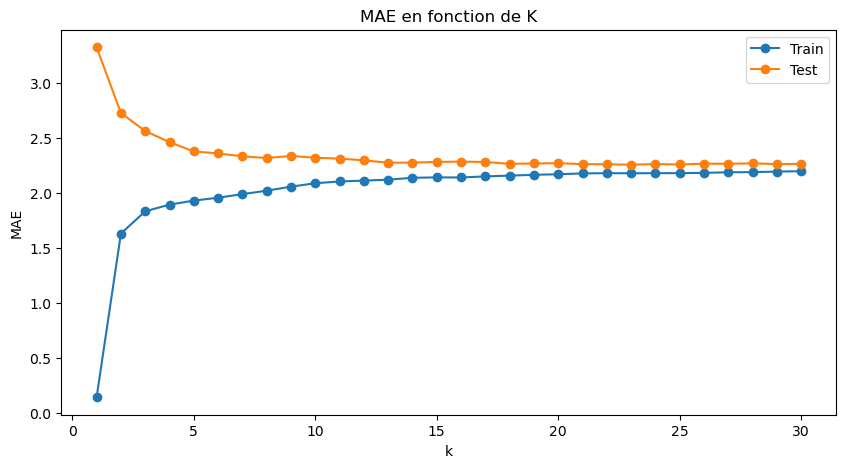

In [50]:
k_values = range(1, 31)
mae_train_list = []
mae_test_list = []

for k in k_values:
    model =KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    mae_train_list.append(mean_absolute_error(y_train, train_pred))
    mae_test_list.append(mean_absolute_error(y_test, test_pred))

plt.figure(figsize=(10,5))

plt.plot(k_values, mae_train_list, marker='o', label='Train') 
plt.plot(k_values, mae_test_list, marker='o', label='Test')
plt.xlabel("k")
plt.ylabel("MAE")
plt.title("MAE en fonction de K")
plt.legend()

plt.show()

In [51]:
best_k = k_values[mae_test_list.index(min(mae_test_list))]
best_mae = min(mae_test_list)

print("Meilleur K :", best_k)
print("Meilleur MAE Test :", round(best_mae, 3))

Meilleur K : 23
Meilleur MAE Test : 2.256


In [57]:
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [58]:
y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)


In [59]:
mae_train_lr = mean_absolute_error(y_train, y_train_pred_lr)
mae_test_lr = mean_absolute_error(y_test, y_test_pred_lr)

print("MAE Train (Regression Lineaire) :", round(mae_train_lr, 3))
print("MAE Test (Regression Lineaire) :", round(mae_test_lr, 3))

MAE Train (Regression Lineaire) : 1.614
MAE Test (Regression Lineaire) : 1.631


In [60]:
coef = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": lr.coef_
})

coef

,Variable,Coefficient
0,Hours Studied,7.362450
1,Previous Scores,17.662606
2,Sleep Hours,0.822814
3,Sample Question Papers Practiced,0.537299
4,Extracurricular Activities_Yes,0.313971


In [62]:
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [63]:
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
y_train_pred_poly = lr_poly.predict(X_train_poly)
y_test_pred_poly = lr_poly.predict(X_test_poly)

mae_train_poly = mean_absolute_error(y_train, y_train_pred_poly)
mae_test_poly = mean_absolute_error(y_test, y_test_pred_poly)

print("MAE Train (Regression Poly) :", round(mae_train_poly, 3))
print("MAE Test (Regression Poly) :", round(mae_test_poly, 3))

MAE Train (Regression Poly) : 1.612
MAE Test (Regression Poly) : 1.634
